#### import library

In [231]:
import  numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,accuracy_score
import warnings as war
war.filterwarnings("ignore")


##### Load the dataset

In [232]:
file_path=r"C:\Users\muham\Downloads\insurance.csv"
df=pd.read_csv(file_path)
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [233]:
df['sex']=df['sex'].replace({
    "male": 1,
    "female":0#54
},inplace=True)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,yes,southwest,16884.92400
1,18,1,33.770,1,no,southeast,1725.55230
2,28,1,33.000,3,no,southeast,4449.46200
3,33,1,22.705,0,no,northwest,21984.47061
4,32,1,28.880,0,no,northwest,3866.85520


In [234]:
df['smoker']=df['smoker'].replace({
    "yes": 1,
    "no":0
},inplace=True)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


In [235]:
df['region'].unique()

<ArrowStringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str

In [236]:
#df=pd.get_dummies(df,columns=['region'])
df.drop(columns=['region'],inplace=True)


In [237]:
df

,age,sex,bmi,children,smoker,charges
0,19,0,27.900,0,1,16884.92400
1,18,1,33.770,1,0,1725.55230
2,28,1,33.000,3,0,4449.46200
3,33,1,22.705,0,0,21984.47061
4,32,1,28.880,0,0,3866.85520
...,...,...,...,...,...,...
1333,50,1,30.970,3,0,10600.54830
1334,18,0,31.920,0,0,2205.98080
1335,18,0,36.850,0,0,1629.83350
1336,21,0,25.800,0,0,2007.94500


In [238]:
df.corr()['charges']

age         0.299008
sex         0.057292
bmi         0.198341
children    0.067998
smoker      0.787251
charges     1.000000
Name: charges, dtype: float64

In [239]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges'], dtype='str')

### to plot the data

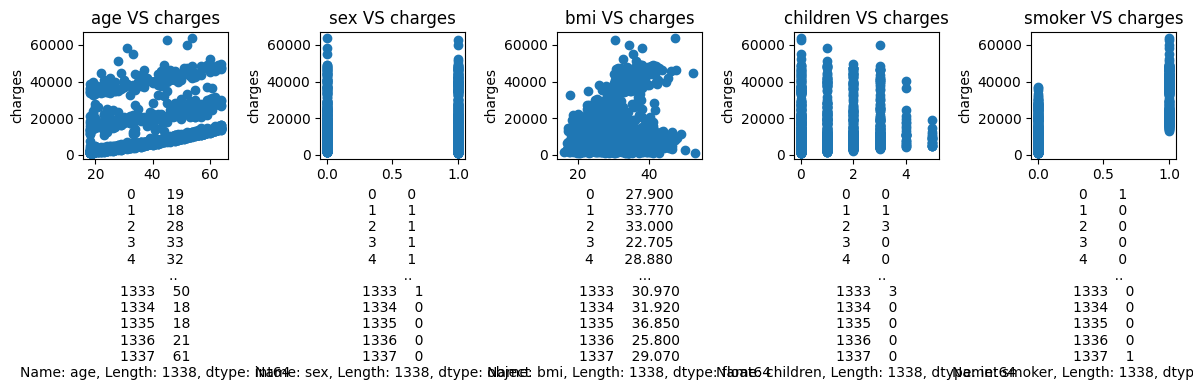

In [240]:
feature=['age', 'sex', 'bmi', 'children', 'smoker']
plt.figure(figsize=(12,4))
for i,col in enumerate(feature):
    plt.subplot(1,5,i+1)
    plt.scatter(df[col],df['charges'])
    plt.xlabel(df[col])
    plt.ylabel("charges")
    plt.title(f"{col} VS charges" )
    plt.tight_layout()

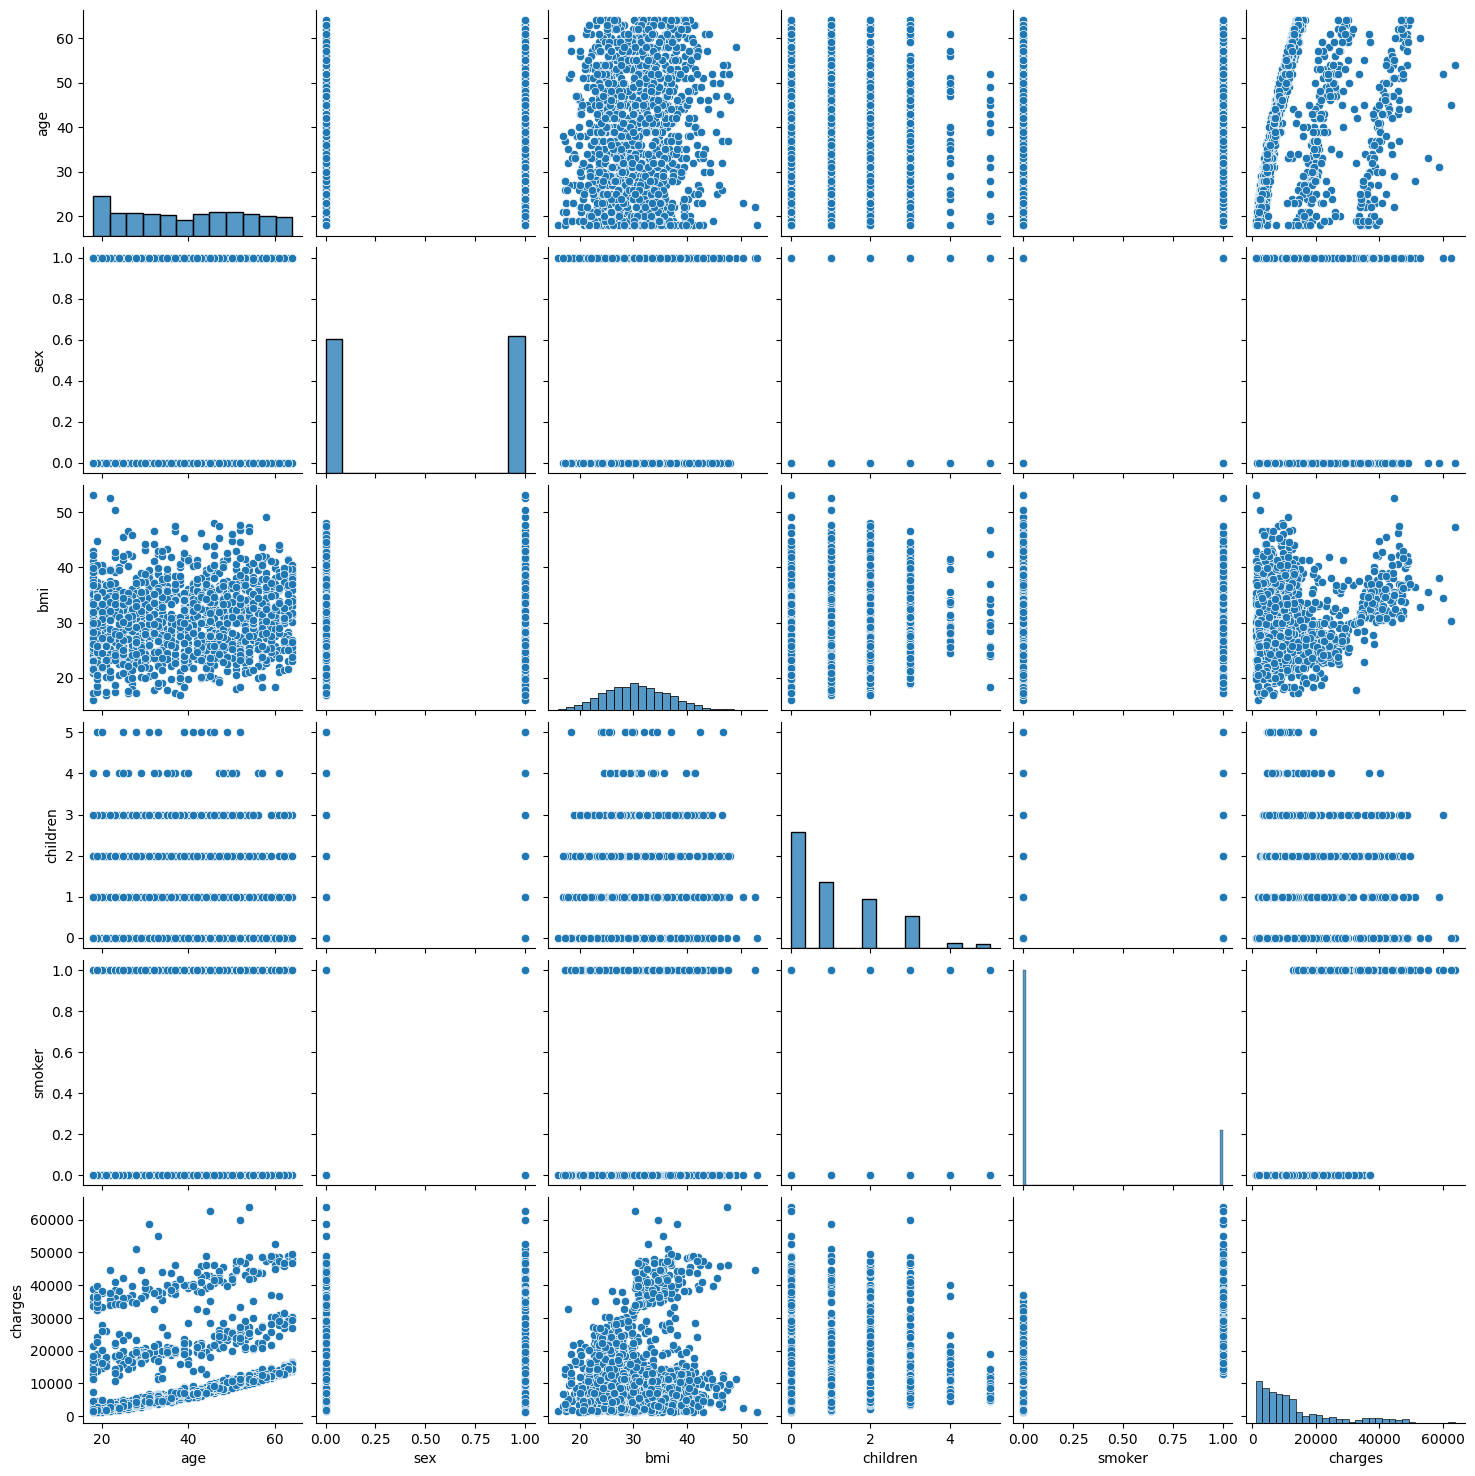

In [241]:
import seaborn as sns
sns.pairplot(df)

#### now lets make the X (indepenent varible and dependent varible)

In [242]:
X=df[feature]
X

,age,sex,bmi,children,smoker
0,19,0,27.900,0,1
1,18,1,33.770,1,0
2,28,1,33.000,3,0
3,33,1,22.705,0,0
4,32,1,28.880,0,0
...,...,...,...,...,...
1333,50,1,30.970,3,0
1334,18,0,31.920,0,0
1335,18,0,36.850,0,0
1336,21,0,25.800,0,0


In [243]:
# X.shape[0]/100* 80

In [244]:
Y=df['charges']
Y


0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

#### lets the split into the dataset into train and test
### we have the traning 80% and for testing 20% 

In [245]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state= 42)
print("The X_train shape:",X_train.shape)
print("The X_test shape:",X_test.shape)
print("The Y_train shape:",Y_train.shape)
print("The Y_test shape:",Y_test.shape)

The X_train shape: (1070, 5)
The X_test shape: (268, 5)
The Y_train shape: (1070,)
The Y_test shape: (268,)


#### now lets create the model object

In [246]:
model=LinearRegression()


### now lets train the model of linear regression


In [247]:
model.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### now we check the model prediction

In [248]:
X_test

,age,sex,bmi,children,smoker
764,45,0,25.175,2,0
887,36,0,30.020,0,0
890,64,0,26.885,0,1
1293,46,1,25.745,3,0
259,19,1,31.920,0,1
...,...,...,...,...,...
109,63,1,35.090,0,1
575,58,0,27.170,0,0
535,38,1,28.025,1,0
543,54,0,47.410,0,1


In [249]:
prediction=model.predict(X_test)
prediction

array([ 8554.81711589,  6973.58746745, 36798.60416104,  9417.88282303,
       26871.68031081, 11097.38383938,   145.27608963, 16746.1683771 ,
         747.53414191, 11153.67590722, 28518.15016561,  9292.18345421,
        5460.51975119, 38510.48013003, 40359.30938604, 37223.40538064,
       15316.56711945, 36047.50032223,  9326.29049907, 31400.1559532 ,
        4269.64414373, 10464.66374097,  2719.9260555 ,  6579.53742551,
       11232.00255515, 12472.06793446, 14807.11281089,  6066.19283362,
        9535.69029723,  2377.6983797 ,  9475.05690885, 12963.23366722,
        4706.09057393,  3414.674504  ,  4815.64981654, 12484.17176954,
        2359.13614479,  9161.02061228, 33238.67621442, 32743.41702445,
        4274.58967205,  4229.5442107 , 14435.36485176, 11384.66898976,
        8925.70468583, 12480.09178788,  5154.45787816,  3554.10047649,
       35649.60942684,  9276.25523701, 15971.35991397,  2552.75200479,
       12162.99980138,  1062.65132285, 13551.43771934, 12103.65505529,
      

In [250]:
prediction.shape

(268,)

In [251]:
prediction[3]

np.float64(9417.882823025828)

### lets evalute the model r2_score: r2_score is evalotion  metirc that determined that how the model learned the data
### formula=R2=1−∑i=1n​(yi​−yˉ​)2∑i=1n​(yi​−y^​i​)2​

In [252]:
r2_score(Y_test,prediction)

0.7811302113434095

### mean squared error :Mean Squared Error (MSE) is one of the most common metrics used to evaluate regression models. It measures the average of the squared differences between the actual values and the predicted values.
### formula=1/2m(Y_pred -Y)**2

In [253]:
print(mean_squared_error(Y_test,prediction))
print(mean_squared_error(prediction,Y_test))

33979257.05080821
33979257.05080821


### mean ablsulte error : is the regression model metric in which determined how the avarge are differnce between the predieted value and actual values

In [254]:
### manully 
np.mean(np.abs(prediction- Y_test))

np.float64(4213.484797807138)

In [255]:
mean_absolute_error(Y_test,prediction)

4213.484797807138

In [256]:
print(Y_test)
prediction[0]

764      9095.06825
887      5272.17580
890     29330.98315
1293     9301.89355
259     33750.29180
           ...     
109     47055.53210
575     12222.89830
535      6067.12675
543     63770.42801
846      9872.70100
Name: charges, Length: 268, dtype: float64


np.float64(8554.817115888558)

### the value of w is 4 becase we have only four faeture 


In [257]:
model.coef_

array([ 2.57068962e+02, -7.95178837e+00,  3.27533514e+02,  4.27254431e+02,
        2.36539033e+04])

### the value of B is one because one bias term

In [258]:
model.intercept_

np.float64(-12113.451250917095)

In [259]:
X.shape

(1338, 5)

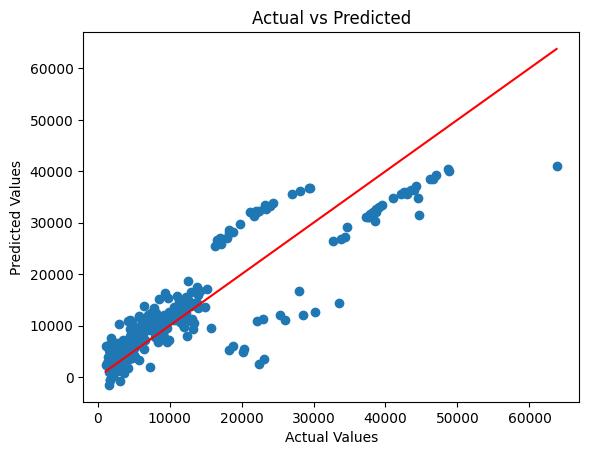

In [260]:
import matplotlib.pyplot as plt

plt.scatter(Y_test, prediction)
plt.plot([Y_test.min(), Y_test.max()],
         [Y_test.min(), Y_test.max()],
         color='red')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

In [261]:
X

,age,sex,bmi,children,smoker
0,19,0,27.900,0,1
1,18,1,33.770,1,0
2,28,1,33.000,3,0
3,33,1,22.705,0,0
4,32,1,28.880,0,0
...,...,...,...,...,...
1333,50,1,30.970,3,0
1334,18,0,31.920,0,0
1335,18,0,36.850,0,0
1336,21,0,25.800,0,0


In [262]:
Y

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

In [263]:
model.predict([[19, 1, 27, 0, 1]])


array([25260.21542422])

In [264]:
from sklearn.metrics import r2_score

# Training predictions
train_pred = model.predict(X_train)

# Test predictions
test_pred = model.predict(X_test)

train_r2 = r2_score(Y_train, train_pred)
test_r2 = r2_score(Y_test, test_pred)

print("Training R²:", train_r2)
print("Test R²:", test_r2)

Training R²: 0.7410888590280913
Test R²: 0.7811302113434095
